# Figures for the technical report: Relative humidity for ESPO¶


In [3]:
import xscen as xs
import xarray as xr
import xclim as xc
from dask.distributed import Client
from xscen import CONFIG
import numpy as np
import cartopy.crs as ccrs
import xsdba as xa

import os
import glob
from matplotlib import pyplot as plt
import figanos.matplotlib as fg
fg.utils.set_mpl_style('ouranos')
xs.load_config("../config/config_general.yml", "../config/config_region.yml", "../config/paths.yml")
cat_rec=xs.DataCatalog(CONFIG['reccat'])
import matplotlib

style_colors = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]

In [2]:
from xclim.core.units import (convert_units_to, declare_units,to_agg_units,)
from xclim.indices.generic import threshold_count
from xclim.core import DayOfYearStr, Quantified
from typing import Literal
def hx_days_above(
    hx: xr.DataArray,
    thresh: Quantified = "30.0 degC",
    freq: str = "YS",
    op: Literal[">", "gt", ">=", "ge"] = ">",
):
    thresh = convert_units_to(thresh, hx)
    f = threshold_count(hx, op, thresh, freq, constrain=(">", ">="))
    return to_agg_units(f, hx, "count", deffreq="D")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


2025-09-08 13:48:34 INFO     xscen.spatial   Loading longitude for more efficient subsetting.
2025-09-08 13:48:37 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 48.55 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 48.47 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


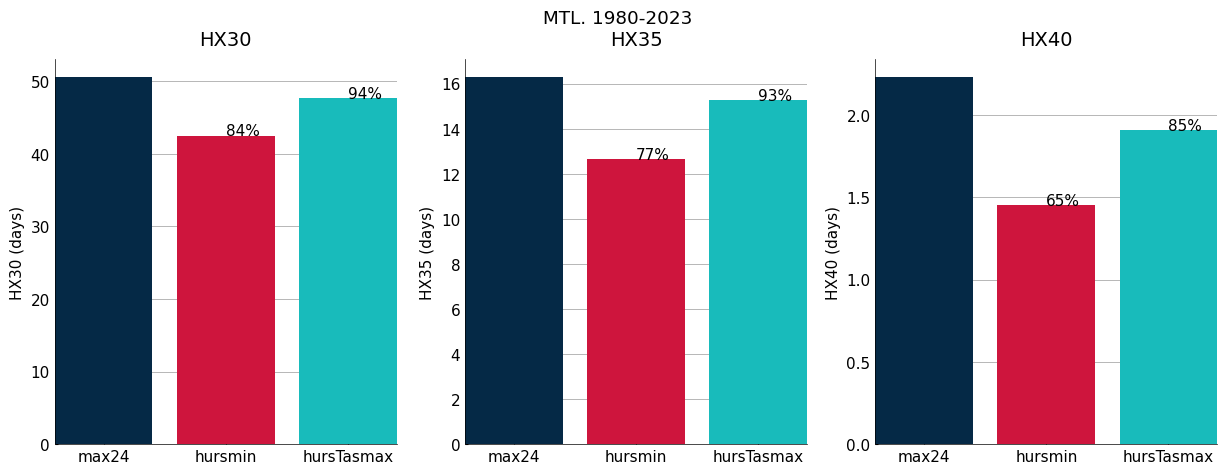

In [15]:
# underestimation
with Client(n_workers=3, threads_per_worker=5, memory_limit="20GB",local_directory=os.environ['SLURM_TMPDIR'],dashboard_address= 6785):
    for coords in [[45.5,-73.6]]:
    
        dsH=cat_rec.search(source='CaSR',variable=['hurs', 'tas'], xrfreq='h').to_dataset()
        region={'name':'mtl','method':'gridpoint','lat':coords[0],'lon':coords[1]}
        dsH=xs.spatial.subset(dsH,**region)

        # when HX max
        humidexH=xc.atmos.humidex(ds=dsH)
        max_humidex_times=humidexH.resample(time='1D').apply(lambda x: x.idxmax('time'))
        dsHxMax = dsH.sel(time=max_humidex_times)
        dsHxMax["time"] = dsHxMax.time.dt.floor('D')
        
        #when tas max
        max_tas_times=dsH.tas.resample(time='1D').apply(lambda x: x.idxmax('time'))
        dsTasMax = dsH.sel(time=max_tas_times)
        dsTasMax["time"] = dsTasMax.time.dt.floor('D')
        
        # humidity
        out=dsH.hurs.resample(time='D').min().to_dataset().rename({'hurs':'hurs_min'})
        out['hurs_min']=dsH.hurs.resample(time='D').min()
        out['hurs_hxmax']= dsHxMax.hurs
        out['hurs_tasmax']= dsTasMax.hurs
        
        # temperature
        out['tas_hxmax']= dsHxMax.tas
        out['tas_tasmax']= dsTasMax.tas
    
        max24 = xc.atmos.humidex(hurs=out['hurs_hxmax'], tas=out['tas_hxmax']).to_dataset()
        hursmin = xc.atmos.humidex(hurs=out['hurs_min'], tas=out['tas_tasmax']).to_dataset()
        hursTasmax = xc.atmos.humidex(hurs=out['hurs_tasmax'], tas=out['tas_tasmax']).to_dataset()
        
        fig,axs=plt.subplots(1,3, figsize=(15,5))
        for j,t in enumerate([30, 35, 40]):
            for i,ds in enumerate([max24,hursmin, hursTasmax]):
                #ind= ds.humidex.where(ds.humidex>t).count().values
                ds.humidex.attrs['units']='degC'
                ind=hx_days_above(ds.humidex, thresh =f"{t} degC").mean(dim='time')
                name=[name for name, val in globals().items() if val is ds][0]
                axs[j].bar(name, ind, )
                if i>0:
                    ind24=hx_days_above(max24.humidex, thresh =f"{t} degC").mean(dim='time')
                    ratio= ind/ind24
                    if ~np.isnan(ratio):
                        axs[j].text(name, ind, f"{int(ratio*100)}%")
            axs[j].set_title(f"HX{t}")
            axs[j].set_ylabel(f"HX{t} (days)")

        fig.suptitle(f"MTL. 1980-2023")

plt.savefig(f"{CONFIG['tmppath']}/figures/underestimation.png")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/dask/array/core.py:5028: PerformanceWarning: Increasing number of chunks by factor of 17
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/dask/array/core.py:5028: PerformanceWarning: Increasing number of chunks by factor of 34


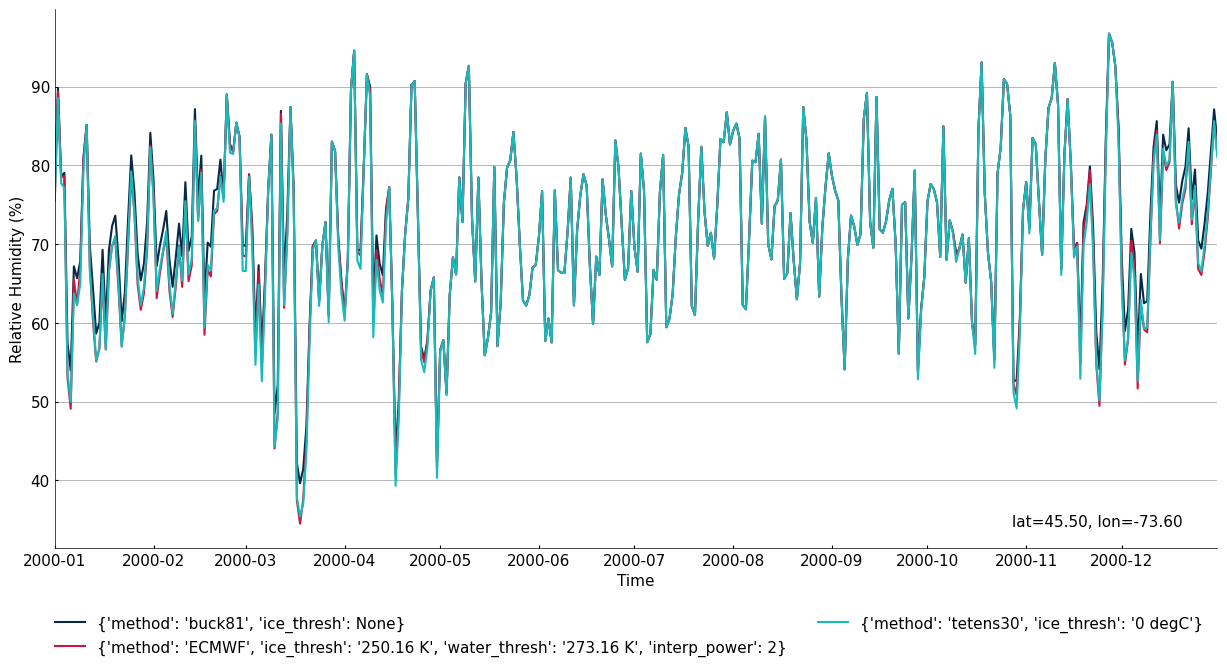

In [4]:
# methods
ds= cat_rec.search(source='ERA5-Land', variable=['tdps','tas', 'huss', 'ps'], xrfreq='D').to_dataset()
ds= xs.spatial.subset(ds, method='gridpoint', lat=45.51,lon=-73.58).sel(time='2000')
fig,ax=plt.subplots(1,1,figsize=(15,7))
for m in [#{"method":"sonntag90", 'ice_thresh':None},
          {"method":"buck81", 'ice_thresh':None},
          dict(method = 'ECMWF', ice_thresh = '250.16 K',water_thresh = '273.16 K',interp_power = 2),
              {"method":"tetens30", 'ice_thresh':'0 degC'},

         ]:
    out = xc.atmos.relative_humidity_from_dewpoint(tas= ds.tas, tdps=ds.tdps,**m)
    #out.plot(label=m)
    fg.timeseries({str(m):out}, ax=ax, show_lat_lon=True)
plt.ylabel('Relative Humidity (%)')
plt.title('', loc='left')
plt.legend(ncol=2, bbox_to_anchor=(1,-0.1))
plt.savefig(f"{CONFIG['tmppath']}/figures/methods.png")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/

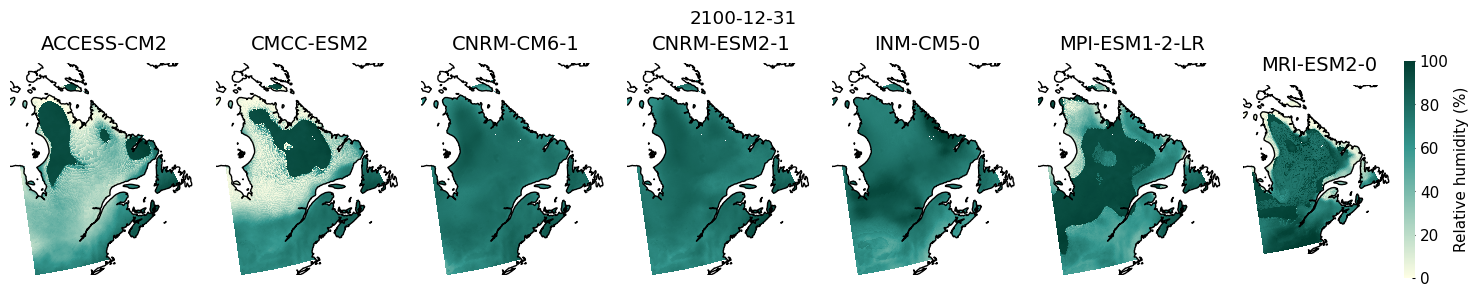

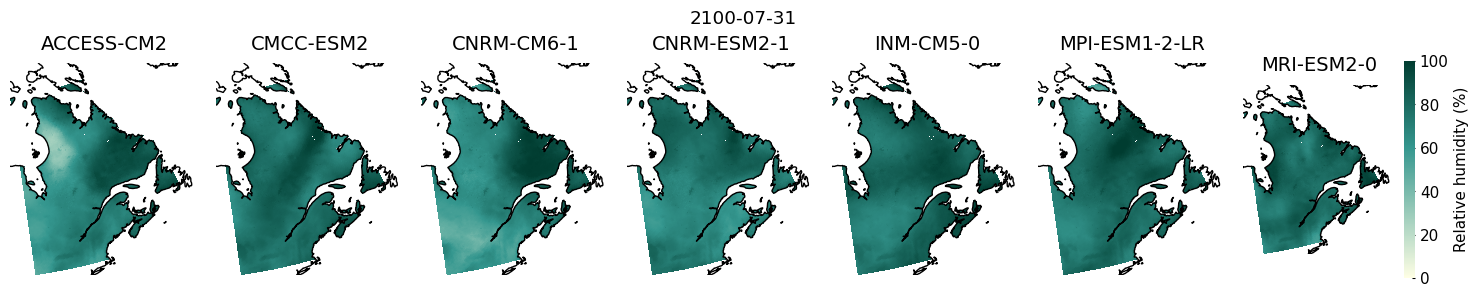

In [17]:
#patches
# weird spots in the winter
source=['ACCESS-CM2', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1',   'INM-CM5-0', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', ]
time='2100-12-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    for e in ['ssp245']:
        f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*{e}*')[0]
        ds= xr.open_zarr(f)
        for var in ds.data_vars:
            fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                       plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
            axs[i].set_title(s)
            i+=1
fig.suptitle(time)
fig.tight_layout()
plt.savefig(f"{CONFIG['tmppath']}/figures/patch-winter.png")
# normal in the summer
time='2100-07-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*ssp245*')[0]
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                   plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
        axs[i].set_title(s)
        i+=1
fig.suptitle(time)
fig.tight_layout()

plt.savefig(f"{CONFIG['tmppath']}/figures/patch-summer.png")

2025-09-08 13:08:18 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-09-08 13:09:05 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-09-08 13:09:47 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


...

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-09-08 13:11:56 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


2025-09-08 13:12:39 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


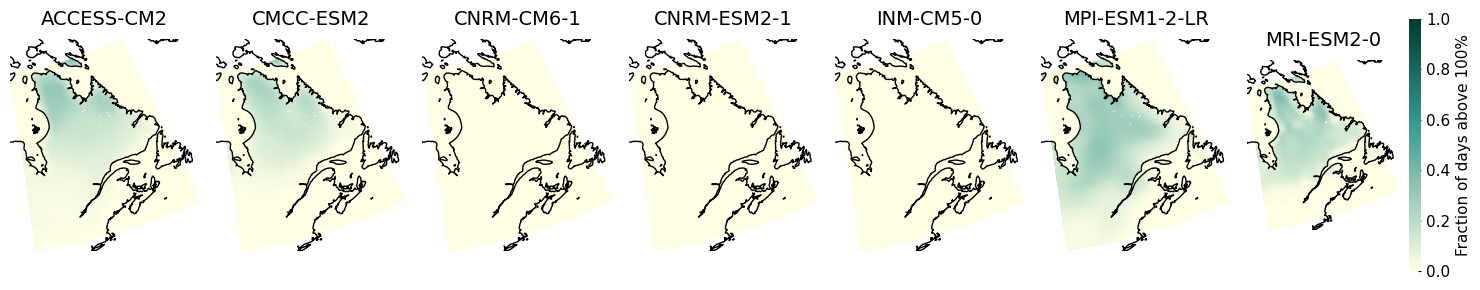

In [6]:
#over 100
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    f=glob.glob(f'{CONFIG['paths']['tmpdir']}/*{s}*regchunked.zarr')[0]
    ds= xr.open_zarr(f)
    ds= xs.utils.unstack_fill_nan(ds)
    count_above_100 = (ds['hurs'] > 100).sum(dim="time")/len(ds.time)
    count_above_100.attrs['long_name']='Fraction of days above 100%'
    fg.gridmap(count_above_100, ax=axs[i],features=['coastline'],
               plot_kw={'vmin':0, 'vmax':1,"add_colorbar": True if i==6 else False},)

    axs[i].set_title(s)
    i+=1
fig.tight_layout()
plt.savefig(f"{CONFIG['tmppath']}/figures/over100.png")

In [ ]:
# dist
lon1=-74
lat1=56
lon2=-71
lat2=56
fig, axs =plt.subplots(1,2, figsize=(15,8), sharex=True, sharey=True)

f=glob.glob(f"{CONFIG['paths']['tmpdir']}/*ACCESS-CM2*regchunked.zarr")[0]

ds= xr.open_zarr(f)
doy = ds['time'].dt.dayofyear
mask = (doy >= 349) | (doy <= 15)
da = ds['hurs'].sel(time=mask).sel(time=slice('1991','2020'))

ds_ref=xr.open_zarr(f"{CONFIG['logit']}/reference/split_regions/QC-E5L_QC-E5L_noleap.zarr.zip")
doy = ds_ref['time'].dt.dayofyear
mask = (doy >= 349) | (doy <= 15)
ds_ref = ds_ref.hurs.sel(time=mask).sel(time=slice('1991','2020'))


f=glob.glob(f"{CONFIG['mulclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*")[0]
ds_mulclip= xr.open_zarr(f)

f=glob.glob(f"{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*")[0]
ds_mulnoclip= xr.open_zarr(f)

f=glob.glob(f"{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*")[0]
ds_logit= xr.open_zarr(f)

i=0
for p in [[lon1,lat1],[lon2,lat2]]:
    da_sub=xs.spatial.subset(da, method='gridpoint', name='p', lon=p[0],lat=p[1])

    #complete dist
    da_sub.quantile(xa.utils.equally_spaced_nodes(50)).plot(marker='.',ax=axs[i], label='complete')

    # clipped
    da_sub= da_sub.astype(float).clip(0,100)
    da_sub.quantile(xa.utils.equally_spaced_nodes(50)).plot(marker='.',ax=axs[i], label='clipped')

    # ref
    da_ref=xs.spatial.subset(ds_ref, method='gridpoint', name='p', lon=p[0],lat=p[1])
    da_ref.quantile(xa.utils.equally_spaced_nodes(50)).plot(marker='.',ax=axs[i], label='reference')


    # future value regridded
    f=glob.glob(f"{CONFIG['paths']['tmpdir']}/*ACCESS-CM2*regchunked.zarr")[0]

    ds= xr.open_zarr(f)
    ds=xs.spatial.subset(ds, method='gridpoint', name='p', lon=p[0],lat=p[1])
    axs[i].axhline(ds.hurs.sel(time='2100-12-31').values, color='black', linestyle=":",label='2100-12-31 value raw')
    
    #logit
    da_sub_logit=xs.spatial.subset(ds_logit, method='gridpoint', name='p', lon=p[0],lat=p[1])
    axs[i].axhline(da_sub_logit.hurs.sel(time='2100-12-31').values, color='orange', linestyle="--",label='2100-12-31 value logit')

    #mulclip
    da_sub_mulclip=xs.spatial.subset(ds_mulclip, method='gridpoint', name='p', lon=p[0],lat=p[1])
    axs[i].axhline(da_sub_mulclip.hurs.sel(time='2100-12-31').values, color=style_colors[1], linestyle="--",label='2100-12-31 value mulclip')

    #mulnoclip
    da_sub_mulnoclip=xs.spatial.subset(ds_mulnoclip, method='gridpoint', name='p', lon=p[0],lat=p[1])
    axs[i].axhline(da_sub_mulnoclip.hurs.sel(time='2100-12-31').values, color=style_colors[0], linestyle="--",label='2100-12-31 value mulnoclip')



    i+=1

axs[0].axvline(0.49, color='black', linestyle=":")
axs[1].axvline(0.15, color='black', linestyle=":")

axs[0].set_ylabel('Relative humidity (%)')
axs[0].set_xlabel('Quantile')
axs[1].set_xlabel('Quantile')
axs[0].set_title('inside patch')
axs[0].set_title('▲', color='red', loc='right')
axs[1].set_title('outside patch')
axs[1].set_title('▼', color='red', loc='right')

plt.legend()
fig.suptitle('DOY 365')
fig.tight_layout()

#plt.savefig(f"{CONFIG['tmppath']}/figures/dist.png")

In [ ]:
#map
time='2100-12-31'
fig, axs =plt.subplots(1,1, figsize=(3,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*')[0]
ds= xr.open_zarr(f)
fg.gridmap(ds['hurs'].sel(time=time), ax=axs,features=['coastline'],
                       plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True },)
axs.set_title('ACCESS-CM2')
fig.suptitle(time)
fig.tight_layout()

lon1=-74
lat1=56
lon2=-71
lat2=56

axs.plot([lon1],[lat1],transform=ccrs.PlateCarree(), color='red', marker='^', label='inside patch', linestyle='none')
axs.plot([lon2],[lat2],transform=ccrs.PlateCarree(), color='red', marker='v', label='outside patch', linestyle='none')
plt.legend(bbox_to_anchor=(0.8,0))
#plt.savefig(f"{CONFIG['tmppath']}/figures/map.png", bbox_inches='tight')

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/

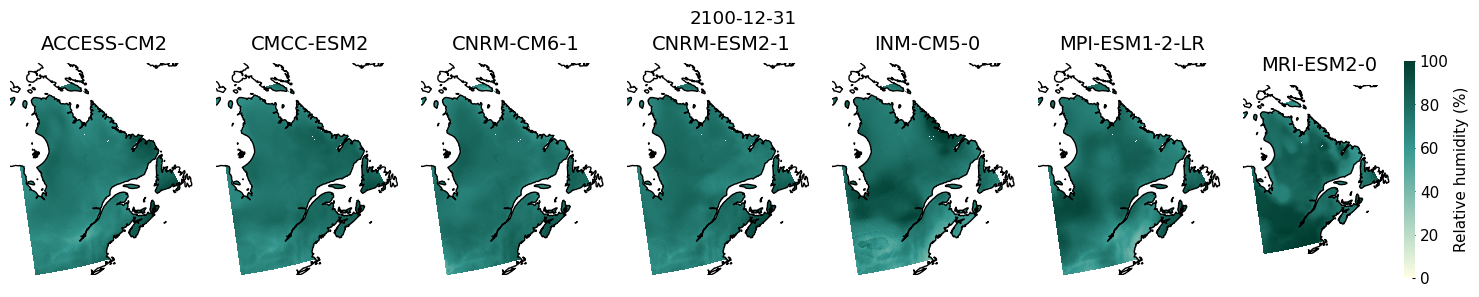

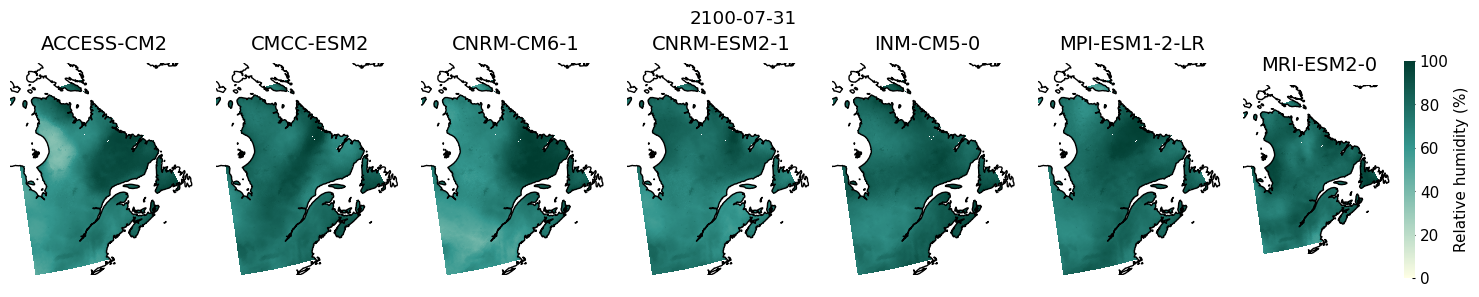

In [5]:
#mul no clip
# no weird spots in the winter
source=['ACCESS-CM2', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1',   'INM-CM5-0', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', ]
time='2100-12-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    for e in ['ssp245']:
        f=glob.glob(f'{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*{e}*')[0]
        ds= xr.open_zarr(f)
        for var in ds.data_vars:
            fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                       plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
            axs[i].set_title(s)
            i+=1
fig.suptitle(time)
fig.tight_layout()
plt.savefig(f"{CONFIG['tmppath']}/figures/mulnoclip-winter.png")

# normal in the summer
time='2100-07-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    f=glob.glob(f'{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*ssp245*')[0]
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                   plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
        axs[i].set_title(s)
        i+=1
fig.suptitle(time)
fig.tight_layout()

plt.savefig(f"{CONFIG['tmppath']}/figures/mulnoclip-summer.png")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-

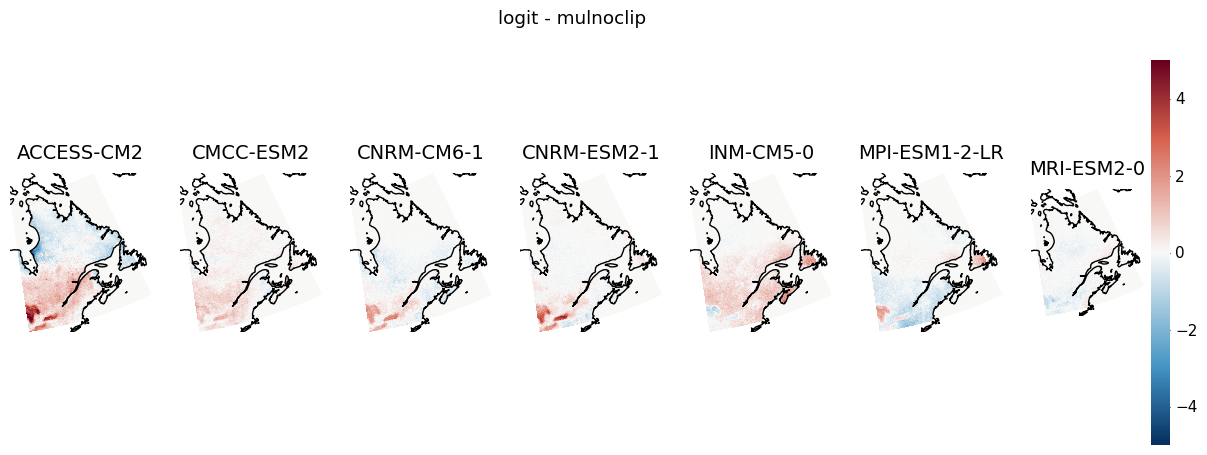

In [9]:
# hx30 logit- mulnoclip
fig, axs =plt.subplots(1,7, figsize=(15,5),subplot_kw=dict(projection=ccrs.LambertConformal()))
i=0


for s in source:
    f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/*/*{s}*ssp245*')
    ds_logit= xr.open_mfdataset(f, engine='zarr').sel(time=slice('2071','2100'))      
    hxmax_logit = xc.atmos.humidex(hurs=ds_logit['hursTasmax'], tas=ds_logit['tasmax']).to_dataset()


    f=glob.glob(f'{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/*/*{s}*ssp245*')
    ds_mulno= xr.open_mfdataset(f, engine='zarr').sel(time=slice('2071','2100'))         
    hxmax_mulno = xc.atmos.humidex(hurs=ds_mulno['hursTasmax'], tas=ds_mulno['tasmax']).to_dataset()


    ind_logit= hx_days_above(hxmax_logit.humidex, thresh=f"30 degC").mean(dim='time')
    ind_mulno= hx_days_above(hxmax_mulno.humidex, thresh=f"30 degC").mean(dim='time')
    # fg.gridmap(ind_logit, ax=axs[0,i],features=['coastline'], cmap='temp_seq',
    #    plot_kw={'vmin':0, 'vmax':130,"add_colorbar": True if i==6 else False},
    #           )
    # fg.gridmap(ind_mulno, ax=axs[1,i],features=['coastline'],cmap='temp_seq',
    #    plot_kw={'vmin':0, 'vmax':130,"add_colorbar": True if i==6 else False},
    #           )

    diff= ind_logit -ind_mulno
    fg.gridmap(diff, ax=axs[i],features=['coastline'],cmap='temp_div',
       plot_kw={'vmin':-5, 'vmax':5,"add_colorbar": True if i==6 else False},
              )
    axs[i].set_title(s)
    i+=1
fig.suptitle('logit - mulnoclip')

plt.savefig(f"{CONFIG['tmppath']}/figures/diff.png")

# extra figures

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.


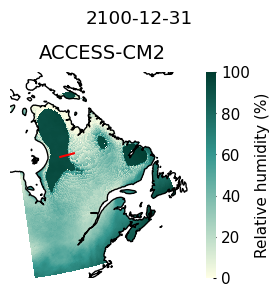

In [10]:
#map
time='2100-12-31'
fig, axs =plt.subplots(1,1, figsize=(3,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*')[0]
ds= xr.open_zarr(f)
fg.gridmap(ds[var].sel(time=time), ax=axs,features=['coastline'],
                       plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True },)
axs.set_title('ACCESS-CM2')
fig.suptitle(time)
fig.tight_layout()

lon1=-74
lat1=56
lon2=-71
lat2=56

axs.plot([lon1,lon2],[lat1,lat2],transform=ccrs.PlateCarree(), color='red')


2025-09-08 13:19:53 INFO     xscen.utils     Dataset unstacked using /project/ctb-frigon/julavoie/DQMmulnoclip/coords/coords_QC-E5L_211x281.nc.


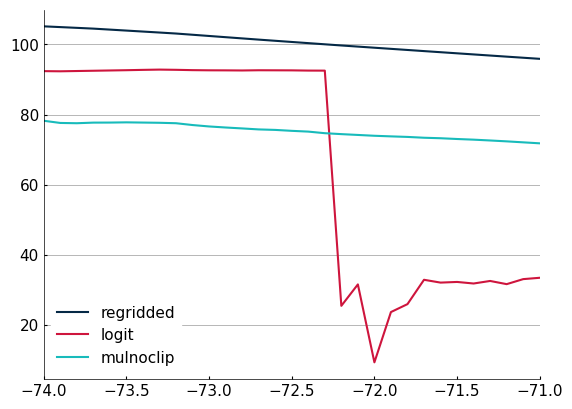

In [11]:
# values along

f=glob.glob(f'{CONFIG['paths']['tmpdir']}/*ACCESS-CM2*regchunked.zarr')[0]
ds= xr.open_zarr(f)
ds= xs.utils.unstack_fill_nan(ds)
ds=ds.sel(lat=56, method='nearest').sel(lon=slice(-74,-71))
ds=ds.hurs.sel(time='2100-12-31')
plt.plot(ds.lon.values, ds.values, label='regridded')


f=glob.glob(f'{CONFIG['logit']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*')[0]
ds= xr.open_zarr(f)
ds=ds.sel(lat=56, method='nearest').sel(lon=slice(-74,-71))
ds=ds.hurs.sel(time='2100-12-31').squeeze()
plt.plot(ds.lon.values, ds.values, label='logit')

f=glob.glob(f'{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*ACCESS-CM2*ssp245*')[0]
ds= xr.open_zarr(f)
ds=ds.sel(lat=56, method='nearest').sel(lon=slice(-74,-71))
ds=ds.hurs.sel(time='2100-12-31').squeeze()
plt.plot(ds.lon.values, ds.values, label='mulnoclip')

plt.legend()
plt.savefig(f"{CONFIG['tmppath']}/figures/line.png")

/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "units" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "long_name" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-

Text(0.5, 0.98, 'Chow et al. - mulnoclip')

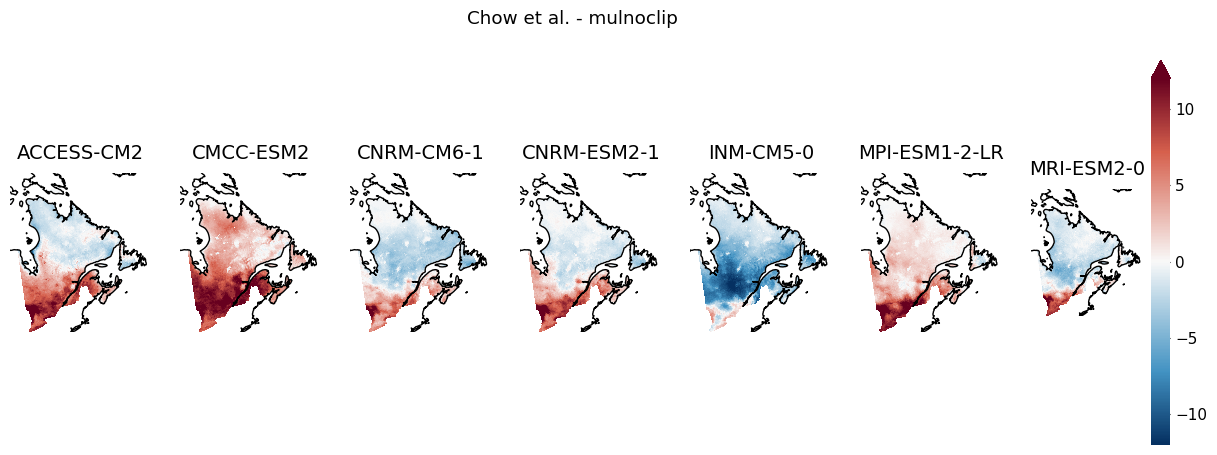

In [12]:
# hx30 chow- mulnoclip
fig, axs =plt.subplots(1,7, figsize=(15,5),subplot_kw=dict(projection=ccrs.LambertConformal()))
i=0


for s in source:
    ds_chow= xr.open_zarr(f"{CONFIG['chow']}/{s}.zarr", decode_timedelta=False).sel(time=slice('2071','2100')).squeeze()
    ind_chow=xs.spatial.subset(ds_chow, method='bbox', name='QC',lon_bnds= [ -83, -55 ],lat_bnds= [ 42, 63.1 ])


    f=glob.glob(f'{CONFIG['mulnoclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/*/*{s}*ssp245*')
    ds_mulno= xr.open_mfdataset(f, engine='zarr').sel(time=slice('2071','2100'))         
    hxmax_mulno = xc.atmos.humidex(hurs=ds_mulno['hursTasmax'], tas=ds_mulno['tasmax']).to_dataset()

    ind_mulno= hx_days_above(hxmax_mulno.humidex, thresh=f"30 degC").mean(dim='time')
    # fg.gridmap(ind_logit, ax=axs[0,i],features=['coastline'], cmap='temp_seq',
    #    plot_kw={'vmin':0, 'vmax':130,"add_colorbar": True if i==6 else False},
    #           )
    # fg.gridmap(ind_mulno, ax=axs[1,i],features=['coastline'],cmap='temp_seq',
    #    plot_kw={'vmin':0, 'vmax':130,"add_colorbar": True if i==6 else False},
    #           )
    ind_chow=ind_chow.reindex(lat=list(reversed(ind_chow.lat)))
    ind_chow['lat']=ind_mulno['lat']
    diff= ind_chow -ind_mulno
    fg.gridmap(diff, ax=axs[i],features=['coastline'],cmap='temp_div',
       plot_kw={'vmin':-12, 'vmax':12,"add_colorbar": True if i==6 else False},
              )
    axs[i].set_title(s)
    i+=1
fig.suptitle('Chow et al. - mulnoclip')



/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:222: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/dqm-np2/lib/

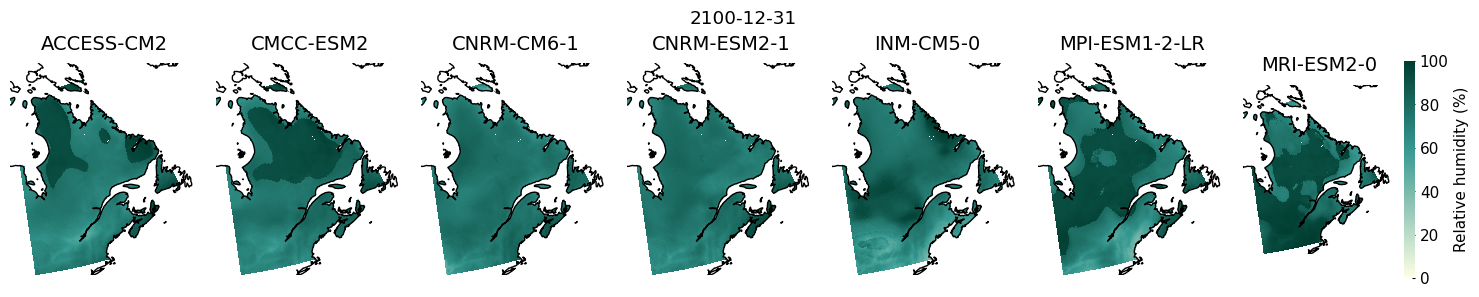

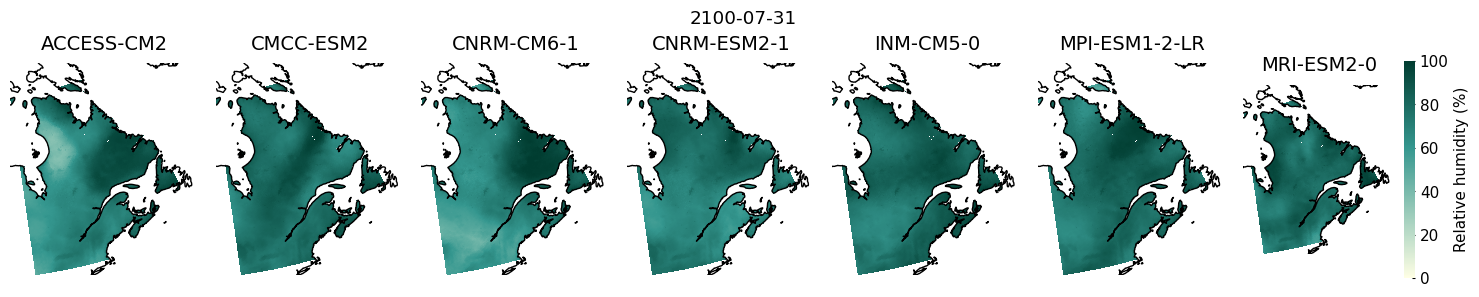

In [13]:
#patches
# weird spots in the winter
source=['ACCESS-CM2', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1',   'INM-CM5-0', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', ]
time='2100-12-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    for e in ['ssp245']:
        f=glob.glob(f'{CONFIG['mulclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*{e}*')[0]
        ds= xr.open_zarr(f)
        for var in ds.data_vars:
            fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                       plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
            axs[i].set_title(s)
            i+=1
fig.suptitle(time)
fig.tight_layout()

# normal in the summer
time='2100-07-31'
fig, axs =plt.subplots(1,7, figsize=(15,3),subplot_kw=dict(projection=ccrs.LambertConformal()))
axs=axs.ravel()
i=0
for s in source:
    f=glob.glob(f'{CONFIG['mulclip']}/staging/simulation/biasadjusted/ESPO-G6-E5L_v11/CMIP6/ScenarioMIP/QC-E5L/*/*/*/*/day/hurs/*{s}*ssp245*')[0]
    ds= xr.open_zarr(f)
    for var in ds.data_vars:
        fg.gridmap(ds[var].sel(time=time), ax=axs[i],features=['coastline'],
                   plot_kw={'vmin':0, 'vmax':100,"add_colorbar": True if i==6 else False},)
        axs[i].set_title(s)
        i+=1
fig.suptitle(time)
fig.tight_layout()

